# Final Comparison — LogReg vs XGBoost vs LSTM

Loads the three family pickles and produces a detailed head-to-head of the **best variant from each family**:

- **LogReg champion** — from `pca_results.pkl` (`logreg_champion` slot)
- **XGBoost champion** — from `pca_results.pkl` (`xgboost_champion` slot)
- **LSTM champion** — from `lstm_results.pkl` (`best_variant` slot)

**Comparisons produced.**

1. Champion identification — variant, feature count, hyperparameters
2. Train accuracy / AUC — deployed-model fit on its final training window (via `logreg_best.pkl` / `xgboost_best.pkl`; LSTM retrained on its rolling-3-year window)
3. Scorecard — train vs test AUC / Accuracy side by side
4. Per-fold AUC trajectory — year folds, COVID fold highlighted
5. Per-fold test accuracy trajectory
6. ROC curves — per-fold grid (3 families × 6 test years)
7. Confusion matrices — per-fold grid
8. Final-fold (2024) head-to-head — overlaid ROC + three CMs
9. Precision / Recall / F1 per-fold comparison
10. Feature importance (where available per family)
11. Verdict — overall winner by non-COVID year-fold AUC

**Prerequisites.** Re-run `Final_baseline_and_PCA.ipynb` and `lstm_all_tests.ipynb` first so that the pickles in `final_outputs/` are in the latest format (the PCA pickle must include the `logreg_champion` / `xgboost_champion` slots).

In [1]:
import sys, os, pickle
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NOTE: xgboost must be imported (and its pickle unpickled) BEFORE torch on macOS.
# Both link against libomp; if torch initializes OpenMP first, later unpickling
# an xgboost Booster segfaults the kernel.
import xgboost  # noqa: F401  — force xgboost's OpenMP runtime first
with open('../final_outputs/xgboost_best.pkl', 'rb') as f: xgb_dep = pickle.load(f)
with open('../final_outputs/logreg_best.pkl',  'rb') as f: logreg_dep = pickle.load(f)

import torch

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score, roc_curve)

from _helpers.pickling import load_results, FINAL_OUTPUTS_DIR
from _helpers.data import (load_dataset, TABULAR_FEATURES, XGBOOST_FEATURES,
                            LSTM_FEATURES, TARGET)
from _helpers.lstm_models import build_sequences, fit_model, evaluate

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

pca  = load_results(f'{FINAL_OUTPUTS_DIR}/pca_results.pkl')
lstm = load_results(f'{FINAL_OUTPUTS_DIR}/lstm_results.pkl')

assert 'logreg_champion' in pca and 'xgboost_champion' in pca, (
    'pca_results.pkl is missing logreg_champion / xgboost_champion slots — '
    're-run Final_baseline_and_PCA.ipynb to regenerate it.')

print(f'LogReg  champion: {pca["logreg_champion"]["name"]}')
print(f'XGBoost champion: {pca["xgboost_champion"]["name"]}')
print(f'LSTM    champion: {lstm["best_variant"]["name"]}')

LogReg  champion: LogReg baseline
XGBoost champion: XGBoost baseline
LSTM    champion: LagCC


## 1. Champions at a glance

Variant name, feature count, and the hyperparameter picked by the final test fold's inner-val search for each family champion.

In [2]:
def nc_mean(values, years):
    nc = [v for v, y in zip(values, years) if y != 2020]
    return float(np.mean(nc)) if nc else np.nan

def _final_hparams(champ):
    hp = champ.get('hyperparams')
    if hp is None:
        return 'n/a'
    if isinstance(hp, dict):
        # e.g. {'best_cs_year': [...]} or {'best_params_year': [...]}
        for k in ('best_params_year', 'best_cs_year', 'best_cs'):
            v = hp.get(k)
            if isinstance(v, list) and v: return v[-1]
            if v is not None and not isinstance(v, list): return v
        return hp
    if isinstance(hp, list) and hp:
        return hp[-1]
    return hp

champions = [
    ('LogReg',  pca['logreg_champion'],  'steelblue',  'o', '-'),
    ('XGBoost', pca['xgboost_champion'], 'darkorange', 's', '--'),
    ('LSTM',    lstm['best_variant'],    'seagreen',   '^', ':'),
]

rows = []
for fam, c, *_ in champions:
    test_yrs = c['yearly']['test_years']
    rows.append({
        'Family':   fam,
        'Variant':  c['name'],
        'Feats':    c['n_features'],
        'Year AUC (nc)': round(nc_mean(c['yearly']['aucs'], test_yrs), 4),
        'Year Acc (nc)': round(nc_mean(c['yearly']['accs'], test_yrs), 4),
        'tscv AUC': (round(float(np.mean(c['tscv']['aucs'])), 4)
                     if c.get('tscv') and c['tscv'].get('aucs') else None),
        'tscv Acc': (round(float(np.mean(c['tscv']['accs'])), 4)
                     if c.get('tscv') and c['tscv'].get('accs') else None),
        'Last-fold hparams': _final_hparams(c),
    })
champ_df = pd.DataFrame(rows)
print(champ_df.to_string(index=False))

 Family          Variant  Feats  Year AUC (nc)  Year Acc (nc)  tscv AUC  tscv Acc                                                                                                              Last-fold hparams
 LogReg  LogReg baseline     18         0.5736         0.5523    0.5899    0.5605                                                                                                                           0.05
XGBoost XGBoost baseline     21         0.5651         0.5475    0.5729    0.5370 {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 3, 'n_estimators': 116}
   LSTM            LagCC     11         0.5565         0.5368    0.5711    0.5418                                                                                            {'hidden_size': 32, 'dropout': 0.3}


## 2. Deployed-model train accuracy

For each champion we fit (or reload) the model on its **final training window** and score on that same training set. Training windows differ by design: LogReg/XGBoost use expanding 2016-2023 (via `logreg_best.pkl` / `xgboost_best.pkl`, fitted once at deployment); LSTM uses rolling 2021-2023 for the 2024 test fold and is retrained here with its final-fold hyperparameters.

The train–test gap is the useful read: a huge gap = overfitting, a small gap with weak test = underfitting.

In [3]:
df_all, primary, _ = load_dataset()
years_series = primary['Year'].reset_index(drop=True)
tickers_all  = primary['Ticker'].reset_index(drop=True)
y_all        = primary[TARGET].reset_index(drop=True)

# ---------- helper that replays the deployable pickle's preprocessing ----------
def _apply_deploy_prep(X_raw, tickers, prep):
    X = X_raw.copy()
    means = tickers.map(prep['obv_stats']['mean']).fillna(prep['obv_mean_fallback'])
    stds  = tickers.map(prep['obv_stats']['std']).fillna(prep['obv_std_fallback']).replace(0, 1)
    X['OBV'] = (X['OBV'].values - means.values) / stds.values
    for col in prep['log1p_features']:
        X[col] = np.log1p(X[col].clip(lower=0))
    X[prep['cols_to_scale']] = prep['scaler'].transform(X[prep['cols_to_scale']])
    return X.values.astype(np.float32)

# ---------- LogReg ----------
lr_mask = years_series.isin(logreg_dep['train_years']).values
X_lr_full = primary[TABULAR_FEATURES].reset_index(drop=True)
X_lr_tr = _apply_deploy_prep(X_lr_full.iloc[lr_mask],
                              tickers_all.iloc[lr_mask], logreg_dep['preprocessing'])
if logreg_dep.get('pca') is not None:
    X_lr_tr = logreg_dep['pca'].transform(X_lr_tr)
lr_train_proba = logreg_dep['model'].predict_proba(X_lr_tr)[:, 1]
y_lr_tr = y_all.iloc[lr_mask].values
lr_train_auc = roc_auc_score(y_lr_tr, lr_train_proba)
lr_train_acc = accuracy_score(y_lr_tr, (lr_train_proba >= 0.5).astype(int))

# ---------- XGBoost ----------
xgb_mask = years_series.isin(xgb_dep['train_years']).values
X_xgb_full = primary[XGBOOST_FEATURES].reset_index(drop=True)
if xgb_dep['k'] is None:
    X_xgb_tr = X_xgb_full.iloc[xgb_mask].values
else:
    X_xgb_tr = _apply_deploy_prep(X_xgb_full.iloc[xgb_mask],
                                    tickers_all.iloc[xgb_mask],
                                    xgb_dep['preprocessing'])
    X_xgb_tr = xgb_dep['pca'].transform(X_xgb_tr)
xgb_train_proba = xgb_dep['model'].predict_proba(X_xgb_tr)[:, 1]
y_xgb_tr = y_all.iloc[xgb_mask].values
xgb_train_auc = roc_auc_score(y_xgb_tr, xgb_train_proba)
xgb_train_acc = accuracy_score(y_xgb_tr, (xgb_train_proba >= 0.5).astype(int))

# ---------- LSTM — retrain champion on its rolling 3-year window (test=2024) ----------
WINDOW   = lstm['meta'].get('window', 4)
lstm_cv  = lstm['best_variant']
lname    = lstm_cv['name']

if lname == 'LagCC':
    lstm_feats = lstm['meta']['lagcc_features']
elif lname == 'DW':
    lstm_feats = lstm['meta']['dw_features']
elif lname == 'Original':
    lstm_feats = lstm['meta']['features_original']
elif lname == 'Aug+LagCC':
    lstm_feats = lstm['meta']['aug_ac_features']
else:
    lstm_feats = lstm['meta'].get('features_original', LSTM_FEATURES)
    print(f'  (warning) approximating "{lname}" with {len(lstm_feats)} Original features for train-acc retrain')

# Build the feature frame - Aug+LagCC needs velocity columns
df_for_lstm = primary.copy()
if lname == 'Aug+LagCC':
    for base in lstm['meta']['features_original']:
        col = f'd_{base}'
        if col not in df_for_lstm.columns:
            df_for_lstm[col] = df_for_lstm.groupby('Ticker')[base].diff().fillna(0)

X_lstm, y_lstm, years_lstm, _ = build_sequences(
    df_for_lstm, lstm_feats, TARGET, WINDOW)

final_train_yrs = [2021, 2022, 2023]
iv_yr  = max(final_train_yrs)
it_yrs = [y for y in final_train_yrs if y != iv_yr]
mi     = np.isin(years_lstm, it_yrs)
vi     = years_lstm == iv_yr
mf     = np.isin(years_lstm, final_train_yrs)

nf = X_lstm.shape[2]
sc = RobustScaler().fit(X_lstm[mf].reshape(-1, nf))
def _prep_lstm(x):
    return sc.transform(x.reshape(-1, nf)).reshape(x.shape).astype(np.float32)

Xv, yv = _prep_lstm(X_lstm[vi]), y_lstm[vi]
Xf, yf = _prep_lstm(X_lstm[mf]), y_lstm[mf]

lstm_params = lstm_cv['hyperparams'][-1] if isinstance(lstm_cv['hyperparams'], list) else lstm_cv['hyperparams']
torch.manual_seed(42); np.random.seed(42)
lstm_model, _ = fit_model(Xf, yf, Xv, yv, **lstm_params)
lstm_train_auc, lstm_train_acc, _ = evaluate(lstm_model, Xf, yf)

train_metrics = {
    'LogReg':  {'auc': lr_train_auc,  'acc': lr_train_acc,  'n_rows': int(lr_mask.sum())},
    'XGBoost': {'auc': xgb_train_auc, 'acc': xgb_train_acc, 'n_rows': int(xgb_mask.sum())},
    'LSTM':    {'auc': float(lstm_train_auc), 'acc': float(lstm_train_acc), 'n_rows': int(mf.sum())},
}
print('Deployed-model train metrics:')
for fam, m in train_metrics.items():
    print(f'  {fam:8s}  AUC={m["auc"]:.4f}  Acc={m["acc"]:.4f}  (n={m["n_rows"]:,})')

Deployed-model train metrics:
  LogReg    AUC=0.6070  Acc=0.5783  (n=7,154)
  XGBoost   AUC=0.8450  Acc=0.7460  (n=7,154)
  LSTM      AUC=0.7848  Acc=0.7007  (n=2,867)


## 3. Scorecard — train vs test AUC / Accuracy

Each family shown with four bars: train AUC, test AUC (non-COVID year-fold mean), train Accuracy, test Accuracy. The gap between train and test bars within the same metric is the generalisation gap.

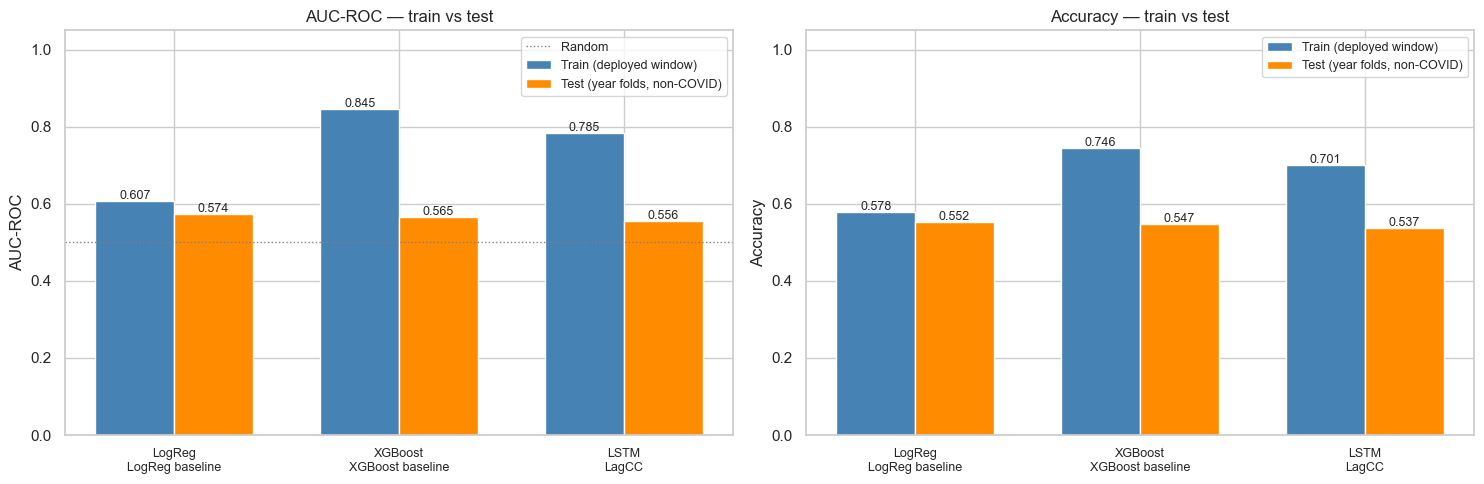

 Family  Train AUC  Test AUC (nc)  AUC gap  Train Acc  Test Acc (nc)  Acc gap
 LogReg     0.6070         0.5736   0.0334     0.5783         0.5523   0.0260
XGBoost     0.8450         0.5651   0.2800     0.7460         0.5475   0.1985
   LSTM     0.7848         0.5565   0.2283     0.7007         0.5368   0.1639


In [4]:
fams = [f for f, *_ in champions]
test_auc  = [nc_mean(c['yearly']['aucs'], c['yearly']['test_years']) for _, c, *_ in champions]
test_acc  = [nc_mean(c['yearly']['accs'], c['yearly']['test_years']) for _, c, *_ in champions]
train_auc = [train_metrics[f]['auc'] for f in fams]
train_acc = [train_metrics[f]['acc'] for f in fams]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
xs = np.arange(len(fams))
w  = 0.35
for ax, train_v, test_v, metric in [
    (axes[0], train_auc, test_auc, 'AUC-ROC'),
    (axes[1], train_acc, test_acc, 'Accuracy'),
]:
    b1 = ax.bar(xs - w/2, train_v, w, color='steelblue',  label='Train (deployed window)')
    b2 = ax.bar(xs + w/2, test_v,  w, color='darkorange', label='Test (year folds, non-COVID)')
    for bars, vals in [(b1, train_v), (b2, test_v)]:
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                     f'{v:.3f}', ha='center', fontsize=9)
    if metric == 'AUC-ROC':
        ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
    ax.set_xticks(xs); ax.set_xticklabels(
        [f'{f}\n{c["name"]}' for f, (_, c, *_) in zip(fams, champions)], fontsize=9)
    ax.set(ylabel=metric, title=f'{metric} — train vs test')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

gap_df = pd.DataFrame({
    'Family': fams,
    'Train AUC': [round(v, 4) for v in train_auc],
    'Test AUC (nc)': [round(v, 4) for v in test_auc],
    'AUC gap': [round(t - te, 4) for t, te in zip(train_auc, test_auc)],
    'Train Acc': [round(v, 4) for v in train_acc],
    'Test Acc (nc)': [round(v, 4) for v in test_acc],
    'Acc gap': [round(t - te, 4) for t, te in zip(train_acc, test_acc)],
})
print(gap_df.to_string(index=False))

## 4. Per-fold AUC trajectory

One line per family across calendar test years 2019–2024. COVID fold shaded.

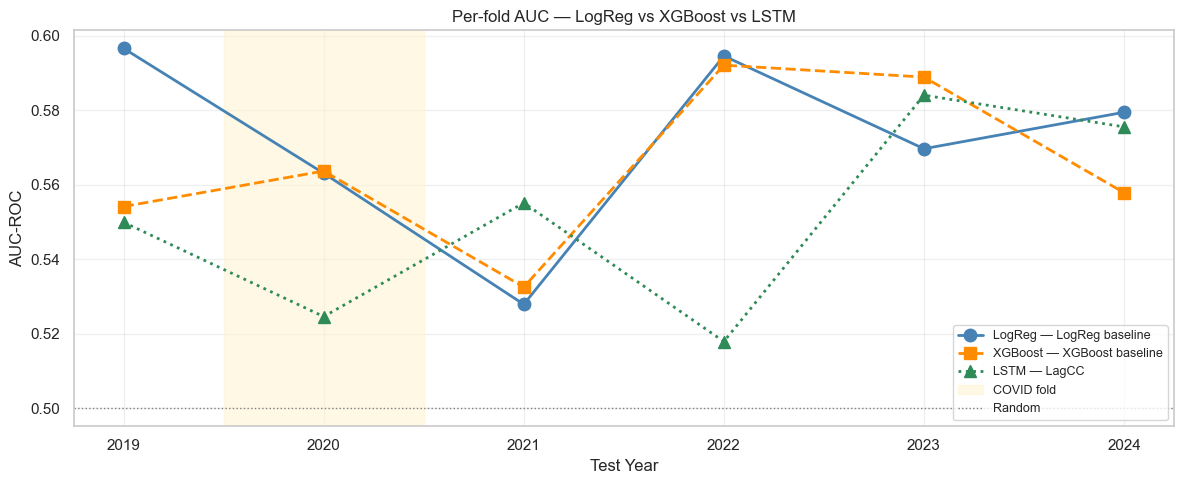

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for fam, c, col, mk, ls in champions:
    ax.plot(c['yearly']['test_years'], c['yearly']['aucs'],
             marker=mk, color=col, lw=2, ls=ls, ms=9,
             label=f'{fam} — {c["name"]}')
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.5, label='COVID fold')
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax.set(xlabel='Test Year', ylabel='AUC-ROC',
        title='Per-fold AUC — LogReg vs XGBoost vs LSTM')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Per-fold test accuracy trajectory

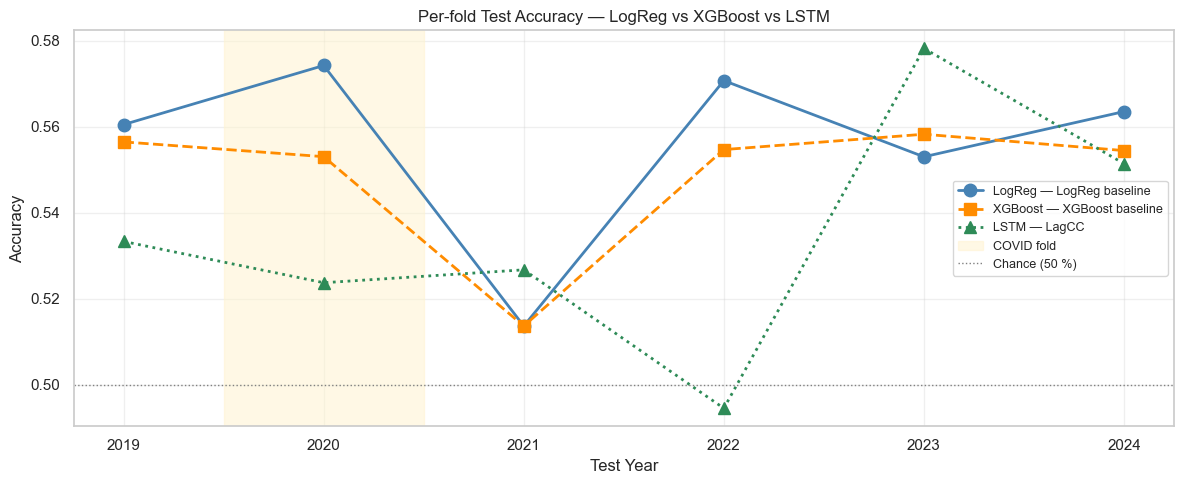

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
for fam, c, col, mk, ls in champions:
    ax.plot(c['yearly']['test_years'], c['yearly']['accs'],
             marker=mk, color=col, lw=2, ls=ls, ms=9,
             label=f'{fam} — {c["name"]}')
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.5, label='COVID fold')
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Chance (50 %)')
ax.set(xlabel='Test Year', ylabel='Accuracy',
        title='Per-fold Test Accuracy — LogReg vs XGBoost vs LSTM')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. ROC curves — per-fold grid

One row per family, one column per test year. Each cell shows the ROC curve for that fold with AUC in the title; the COVID column is tinted.

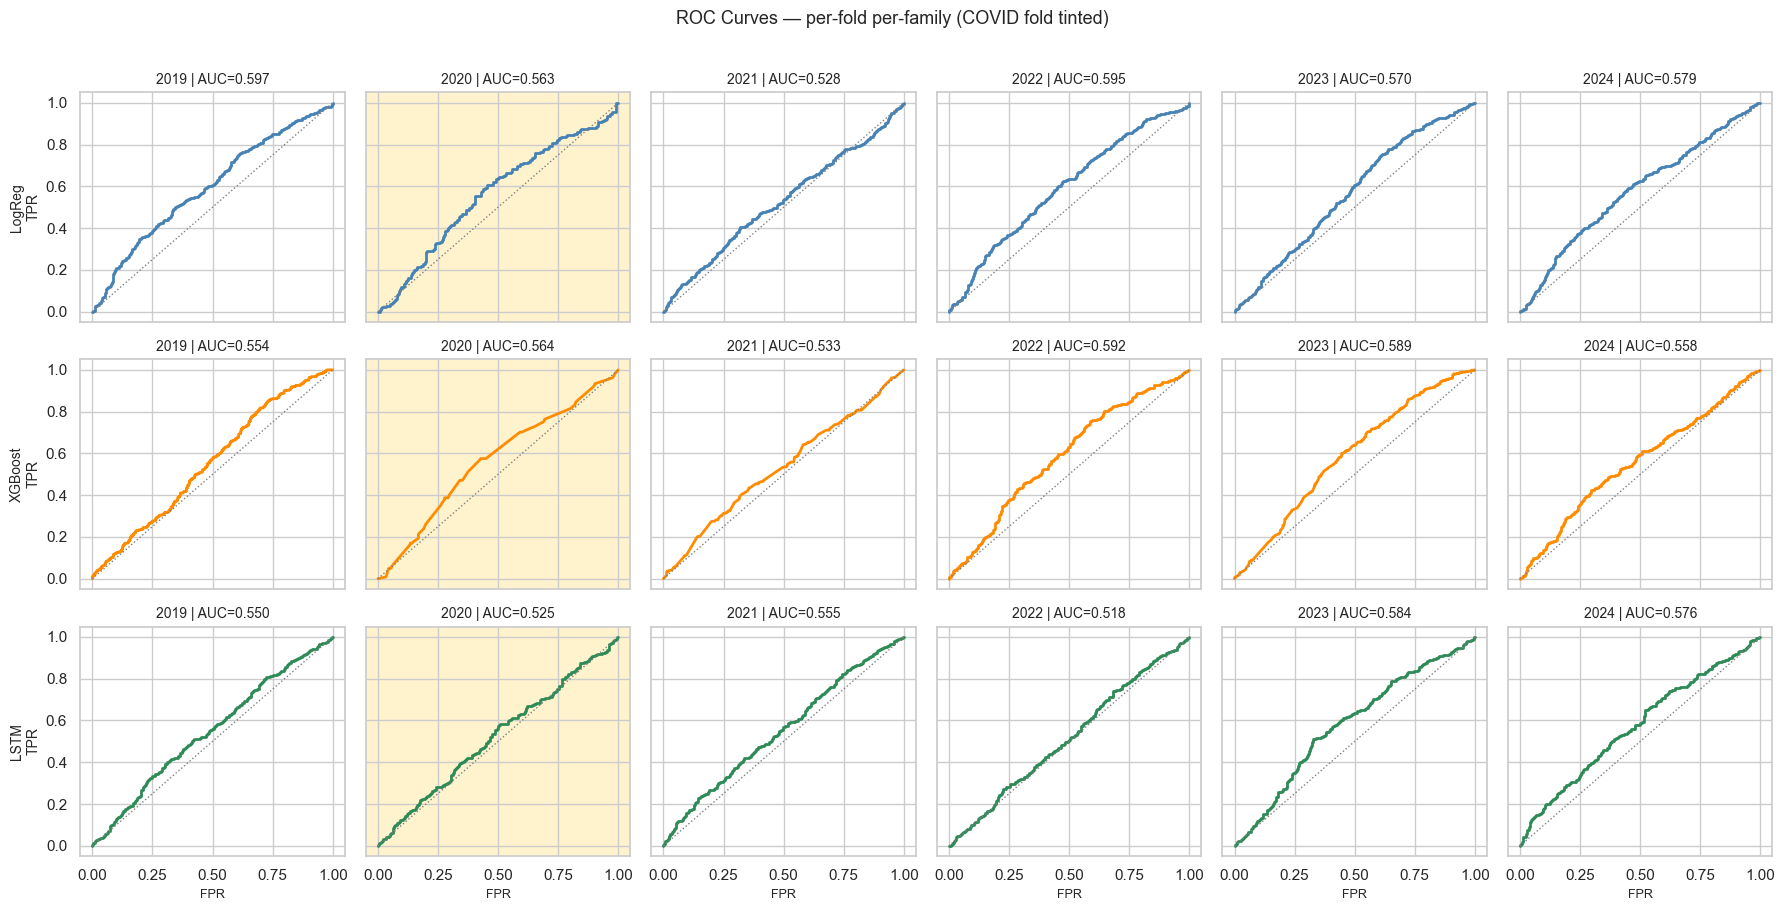

In [7]:
test_years_ref = champions[0][1]['yearly']['test_years']
n_cols = len(test_years_ref)
fig, axes = plt.subplots(3, n_cols, figsize=(3 * n_cols, 9), sharex=True, sharey=True)
for r, (fam, c, col, _, _) in enumerate(champions):
    rocs = c['yearly'].get('rocs')
    aucs = c['yearly']['aucs']
    years_row = c['yearly']['test_years']
    for ci, yr in enumerate(test_years_ref):
        ax = axes[r, ci]
        if rocs is None or yr not in years_row:
            ax.text(0.5, 0.5, 'no ROC\navailable',
                     ha='center', va='center', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        idx = years_row.index(yr)
        fpr, tpr = rocs[idx]
        ax.plot(fpr, tpr, color=col, lw=2)
        ax.plot([0, 1], [0, 1], color='grey', ls=':', lw=1)
        ax.set_title(f'{yr} | AUC={aucs[idx]:.3f}', fontsize=10)
        if yr == 2020: ax.set_facecolor('#fff3cd')
        if r == 2: ax.set_xlabel('FPR', fontsize=9)
        if ci == 0: ax.set_ylabel(f'{fam}\nTPR', fontsize=10)
plt.suptitle('ROC Curves — per-fold per-family (COVID fold tinted)',
              fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 7. Confusion matrices — per-fold grid

Same layout as the ROC grid, annotated with per-cell count. Diagonals = correct predictions.

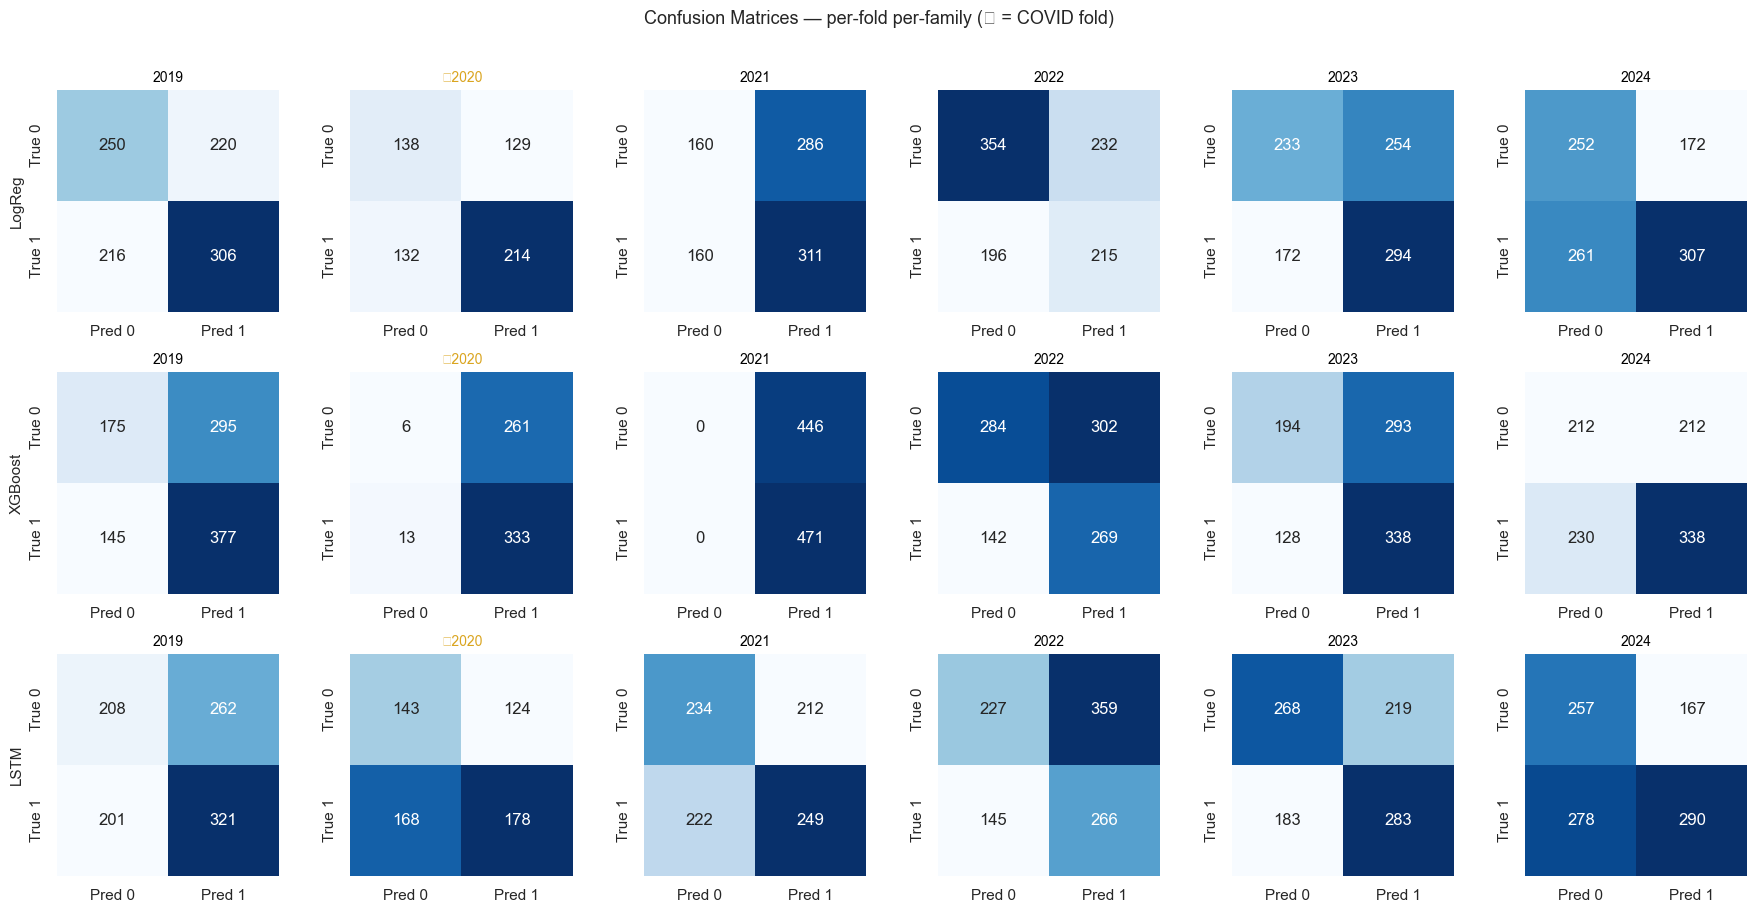

In [8]:
fig, axes = plt.subplots(3, n_cols, figsize=(3 * n_cols, 9))
for r, (fam, c, col, _, _) in enumerate(champions):
    cms = c['yearly'].get('cms')
    years_row = c['yearly']['test_years']
    for ci, yr in enumerate(test_years_ref):
        ax = axes[r, ci]
        if cms is None or yr not in years_row:
            ax.text(0.5, 0.5, 'no CM\navailable',
                     ha='center', va='center', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        idx = years_row.index(yr)
        cm = np.asarray(cms[idx])
        sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax,
                     cmap='Blues', square=True,
                     xticklabels=['Pred 0', 'Pred 1'],
                     yticklabels=['True 0', 'True 1'])
        title_prefix = '★' if yr == 2020 else ''
        ax.set_title(f'{title_prefix}{yr}', fontsize=10,
                     color=('goldenrod' if yr == 2020 else 'black'))
        if ci == 0: ax.set_ylabel(fam, fontsize=11)
plt.suptitle('Confusion Matrices — per-fold per-family (★ = COVID fold)',
              fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 8. Final-fold (2024) head-to-head

The most-recent hold-out year — the fold closest to what production would see. Overlaid ROC curves on the left; three confusion matrices side by side on the right.

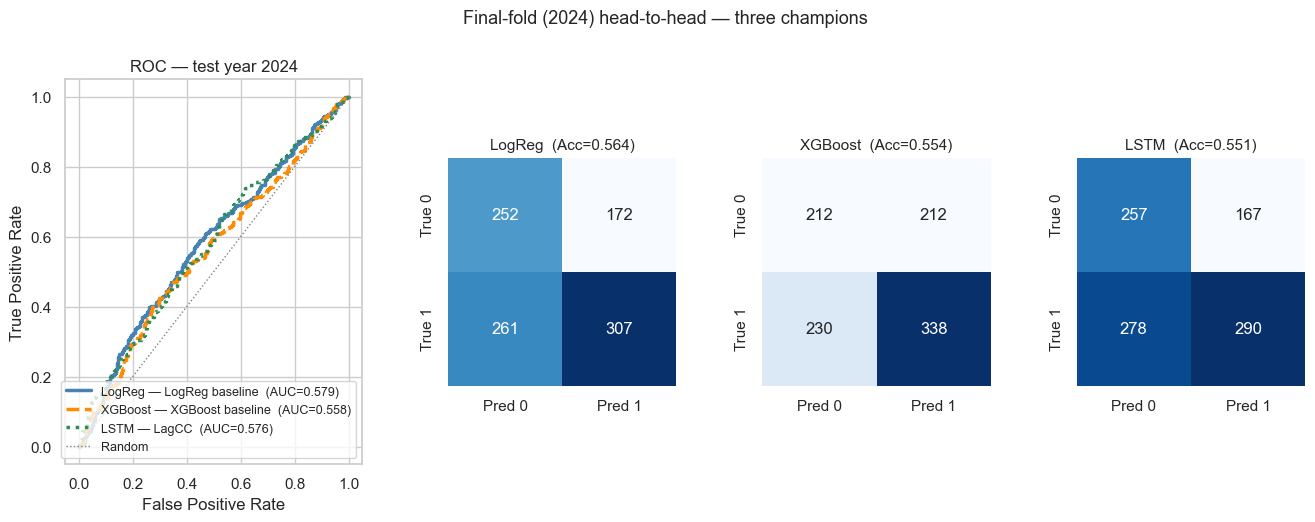

In [9]:
LAST_YR = 2024
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1.3, 1, 1, 1], wspace=0.35)
ax_roc = fig.add_subplot(gs[0])
cm_axes = [fig.add_subplot(gs[i + 1]) for i in range(3)]

for (fam, c, col, mk, ls), cm_ax in zip(champions, cm_axes):
    years_row = c['yearly']['test_years']
    if LAST_YR not in years_row:
        cm_ax.text(0.5, 0.5, f'{fam}: no 2024 fold',
                    ha='center', va='center')
        cm_ax.set_axis_off(); continue
    idx = years_row.index(LAST_YR)
    rocs = c['yearly'].get('rocs')
    cms  = c['yearly'].get('cms')
    if rocs:
        fpr, tpr = rocs[idx]
        ax_roc.plot(fpr, tpr, color=col, lw=2.5, ls=ls,
                     label=f'{fam} — {c["name"]}  (AUC={c["yearly"]["aucs"][idx]:.3f})')
    if cms is not None:
        cm = np.asarray(cms[idx])
        sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=cm_ax,
                     cmap='Blues', square=True,
                     xticklabels=['Pred 0', 'Pred 1'],
                     yticklabels=['True 0', 'True 1'])
        acc = c['yearly']['accs'][idx]
        cm_ax.set_title(f'{fam}  (Acc={acc:.3f})', fontsize=11)

ax_roc.plot([0, 1], [0, 1], color='grey', ls=':', lw=1, label='Random')
ax_roc.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title=f'ROC — test year {LAST_YR}')
ax_roc.legend(fontsize=9, loc='lower right')
plt.suptitle(f'Final-fold ({LAST_YR}) head-to-head — three champions',
              fontsize=13, y=1.02)
plt.show()

## 9. Precision / Recall / F1 — per-fold comparison

Precision / Recall / F1 for each family across the six test years. LogReg and XGBoost don't carry these in the pickle — we recompute them from the stored confusion matrices. LSTM ships them directly.

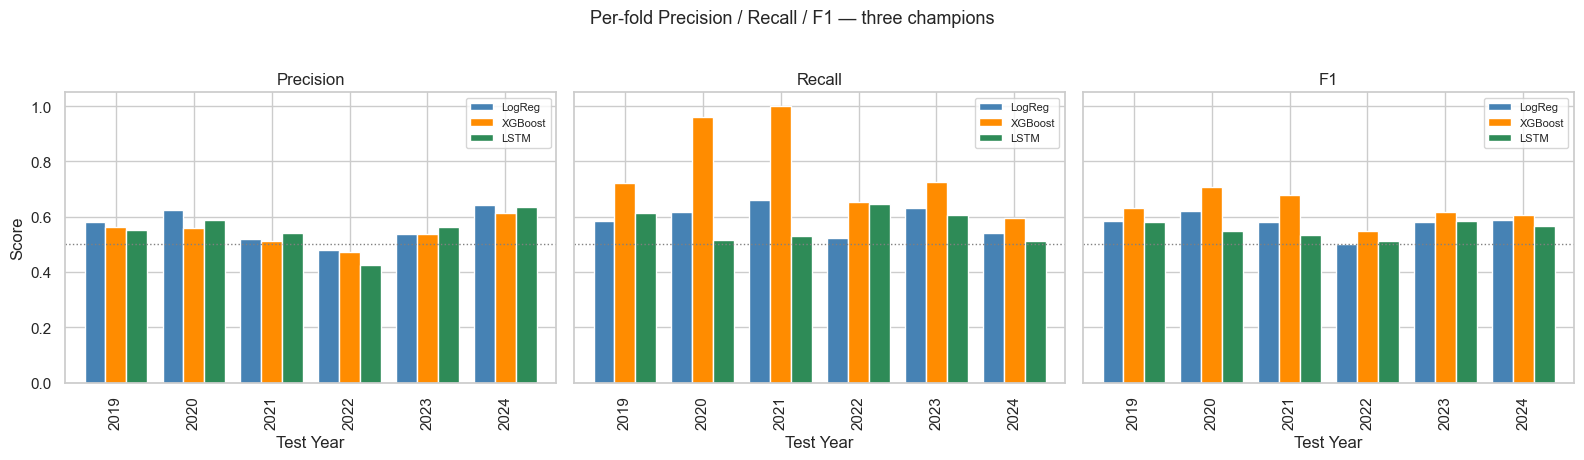


Non-COVID means:
         Precision  Recall      F1
Family                            
LSTM        0.5429  0.5817  0.5559
LogReg      0.5522  0.5882  0.5668
XGBoost     0.5392  0.7394  0.6158


In [10]:
def _prf_from_cm(cm):
    cm = np.asarray(cm)
    if cm.shape != (2, 2):
        return (np.nan,) * 3
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return prec, rec, f1

def _prf_for_champion(c):
    if 'precisions' in c['yearly'] and c['yearly']['precisions']:
        return (c['yearly']['precisions'],
                c['yearly']['recalls'],
                c['yearly']['f1s'])
    cms = c['yearly'].get('cms')
    if not cms: return ([np.nan]*len(c['yearly']['test_years']),) * 3
    precs, recs, f1s = [], [], []
    for cm in cms:
        p, r, f = _prf_from_cm(cm); precs.append(p); recs.append(r); f1s.append(f)
    return precs, recs, f1s

rows = []
for fam, c, *_ in champions:
    prec, rec, f1 = _prf_for_champion(c)
    tys = c['yearly']['test_years']
    for yr, p, r, fsc in zip(tys, prec, rec, f1):
        rows.append({'Family': fam, 'Year': yr, 'Precision': p, 'Recall': r, 'F1': fsc})
prf_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1']):
    piv = prf_df.pivot(index='Year', columns='Family', values=metric)
    piv = piv[[f for f, *_ in champions]]
    piv.plot(kind='bar', ax=ax,
              color=['steelblue', 'darkorange', 'seagreen'], width=0.8)
    ax.set_title(metric); ax.set_xlabel('Test Year')
    ax.axhline(0.5, color='grey', ls=':', lw=1)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Score')
plt.suptitle('Per-fold Precision / Recall / F1 — three champions', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print('\nNon-COVID means:')
nc_rows = prf_df[prf_df['Year'] != 2020]
print(nc_rows.groupby('Family')[['Precision', 'Recall', 'F1']].mean().round(4).to_string())

## 10. Feature importance — champions

Importance lives on different scales per family (L1 coefficient magnitude for LogReg, split gain for XGBoost, permutation AUC-drop for LSTM) — ranks are still comparable within each panel.

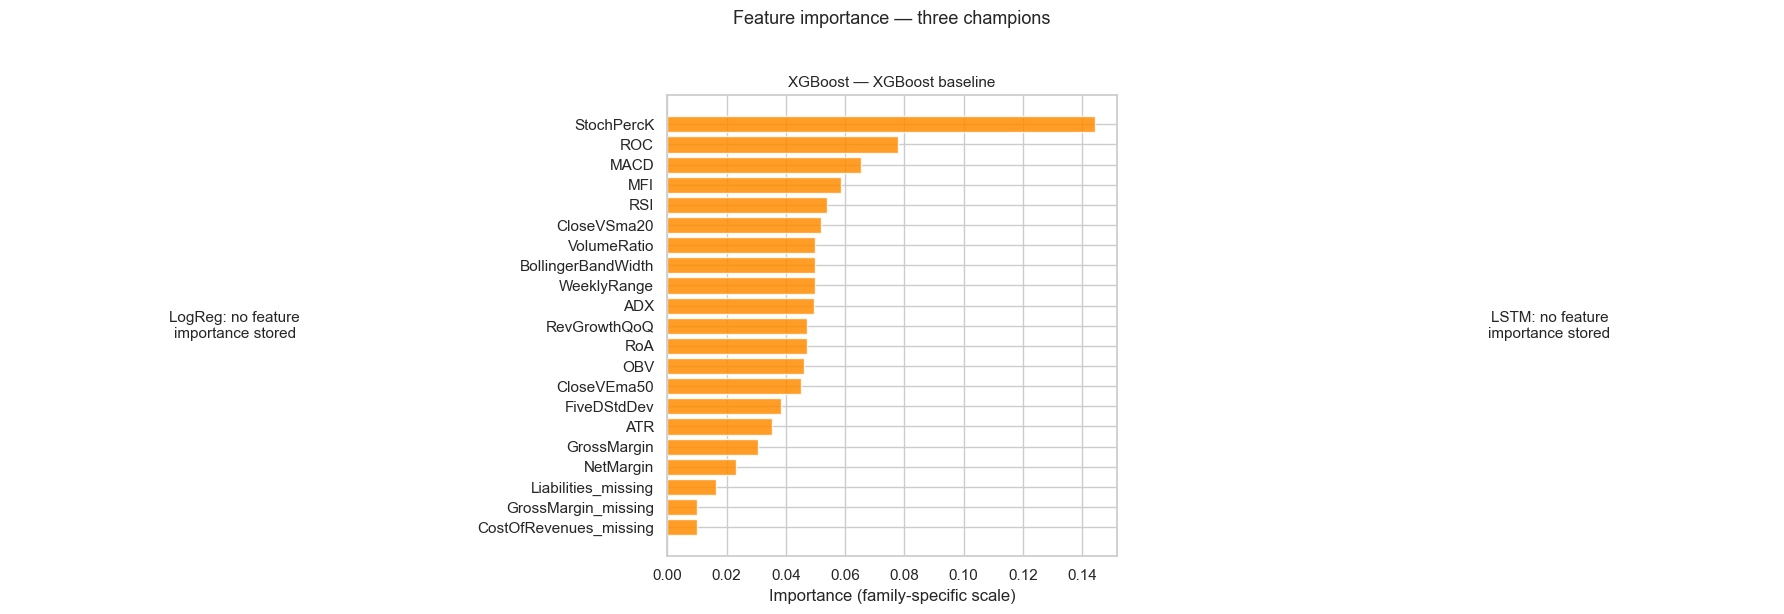

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (fam, c, col, *_) in zip(axes, champions):
    imp = c.get('feature_importance')
    if not imp:
        ax.text(0.5, 0.5, f'{fam}: no feature\nimportance stored',
                 ha='center', va='center', fontsize=11)
        ax.set_axis_off(); continue
    s = pd.Series(imp).sort_values()
    ax.barh(s.index, s.values, color=col, alpha=0.85)
    ax.set_title(f'{fam} — {c["name"]}', fontsize=11)
    ax.set_xlabel('Importance (family-specific scale)')
plt.suptitle('Feature importance — three champions', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 11. Verdict — who wins?

Rank the three champions by (a) non-COVID year-fold AUC, (b) tscv AUC, (c) generalisation gap (train - test AUC). A family that wins all three is an unambiguous overall winner; otherwise we report each ranking.

In [12]:
score_rows = []
for fam, c, *_ in champions:
    ty = c['yearly']['test_years']
    test_auc_v  = nc_mean(c['yearly']['aucs'], ty)
    test_acc_v  = nc_mean(c['yearly']['accs'], ty)
    tscv_auc_v  = (float(np.mean(c['tscv']['aucs']))
                    if c.get('tscv') and c['tscv'].get('aucs') else np.nan)
    tauc = train_metrics[fam]['auc']
    tacc = train_metrics[fam]['acc']
    score_rows.append({
        'Family':       fam,
        'Variant':      c['name'],
        'Train AUC':    round(tauc, 4),
        'Test AUC':     round(test_auc_v, 4),
        'AUC gap':      round(tauc - test_auc_v, 4),
        'Train Acc':    round(tacc, 4),
        'Test Acc':     round(test_acc_v, 4),
        'Acc gap':      round(tacc - test_acc_v, 4),
        'tscv AUC':     round(tscv_auc_v, 4) if not np.isnan(tscv_auc_v) else None,
    })
score_df = pd.DataFrame(score_rows)
print(score_df.to_string(index=False))

winner_year_auc = score_df.loc[score_df['Test AUC'].idxmax(), 'Family']
winner_tscv_auc = (score_df.loc[score_df['tscv AUC'].idxmax(), 'Family']
                   if score_df['tscv AUC'].notna().any() else 'n/a')
winner_smallest_gap = score_df.loc[score_df['AUC gap'].idxmin(), 'Family']

print()
print('=' * 60)
print('RANKINGS')
print('=' * 60)
print(f'Winner (non-COVID year-fold AUC) : {winner_year_auc}')
print(f'Winner (tscv AUC)                : {winner_tscv_auc}')
print(f'Smallest train-test AUC gap      : {winner_smallest_gap}')
overall = (winner_year_auc
           if winner_year_auc == winner_tscv_auc
           else f'split: year={winner_year_auc}, tscv={winner_tscv_auc}')
print(f'Overall                          : {overall}')
print('=' * 60)

 Family          Variant  Train AUC  Test AUC  AUC gap  Train Acc  Test Acc  Acc gap  tscv AUC
 LogReg  LogReg baseline     0.6070    0.5736   0.0334     0.5783    0.5523   0.0260    0.5899
XGBoost XGBoost baseline     0.8450    0.5651   0.2800     0.7460    0.5475   0.1985    0.5729
   LSTM            LagCC     0.7848    0.5565   0.2283     0.7007    0.5368   0.1639    0.5711

RANKINGS
Winner (non-COVID year-fold AUC) : LogReg
Winner (tscv AUC)                : LogReg
Smallest train-test AUC gap      : LogReg
Overall                          : LogReg
